# Week 3 — Cohort Retention Analysis & Churn Prediction

**Goal:** Visualise the cohort retention matrix and evaluate the churn prediction model built in `src/cohorts.py` and `src/churn_model.py`.

**Inputs:**
- `data/cohort_retention.csv` — monthly retention matrix (% of each cohort still active)
- `data/churn_labels.csv` — every customer with churn label, features, and model predictions
- `data/churn_model.joblib` — trained XGBoost model
- `data/churn_scaler.joblib` — fitted StandardScaler

**Outputs:** 8 plots saved to `reports/`

Run cells top to bottom. Read every markdown cell — they contain the business interpretation of each chart.

## Cell 1 — Imports and settings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib
import shap
import mlflow
import warnings
from pathlib import Path
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    confusion_matrix, RocCurveDisplay
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.0)
plt.rcParams.update({'figure.dpi': 110, 'figure.facecolor': 'white'})

# Consistent colours used across all plots in this notebook
BLUE   = '#185FA5'
TEAL   = '#0F6E56'
AMBER  = '#854F0B'
CORAL  = '#993C1D'
GREY   = '#888882'

# Feature columns used by the churn model
# Must match FEATURE_COLS in src/churn_model.py exactly
FEATURE_COLS = [
    'Frequency', 'Monetary', 'F_Score', 'M_Score',
    'avg_days_between_orders', 'order_gap_std',
    'product_diversity', 'CLV_capped'
]

ROOT    = Path('..').resolve()
RPT_DIR = ROOT / 'reports'
RPT_DIR.mkdir(exist_ok=True)

print('Imports done.')
print(f'Project root : {ROOT}')

Imports done.
Project root : C:\Users\aishw\Documents\customer_segmentation


## Cell 2 — Load all data

In [12]:
# Load cohort retention matrix
# Index = cohort month strings (e.g. '2010-01')
# Columns = months since acquisition (0, 1, 2 ...)
retention = pd.read_csv(
    ROOT / 'data' / 'cohort_retention.csv',
    index_col=0
)
retention.columns = retention.columns.astype(int)

# Load churn labels + features + predictions
churn_df = pd.read_csv(ROOT / 'data' / 'churn_labels.csv')

# Load model and scaler (for SHAP analysis)
model  = joblib.load(ROOT / 'data' / 'churn_model.joblib')
scaler = joblib.load(ROOT / 'data' / 'churn_scaler.joblib')

print(f'Retention matrix : {retention.shape}  (cohorts x months)')
print(f'Churn dataset    : {churn_df.shape}')
print(f'Columns          : {list(churn_df.columns)}')
print()

# Split into labelled subsets for evaluation
# All customers now have Churn_Pred (full-dataset prediction was applied)
# Use the Split column to isolate the held-out test set for honest evaluation
# Training set predictions are optimistic (model saw those customers during training)
# so we ONLY use the test split for metrics like ROC-AUC, F1, confusion matrix

test_df = churn_df[churn_df['Split'] == 'test'].copy()
y_test  = test_df['Churned'].astype(int)
y_pred  = test_df['Churn_Pred'].astype(int)
y_prob  = test_df['Churn_Prob']

print(f'Total customers  : {len(churn_df):,}')
print(f'Test set         : {len(test_df):,} customers  (used for all metrics below)')
print(f'Train set        : {(churn_df["Split"] == "train").sum():,} customers  (excluded from metrics)')
print(f'Churn rate (test): {y_test.mean()*100:.1f}%')

Retention matrix : (25, 25)  (cohorts x months)
Churn dataset    : (5796, 26)
Columns          : ['Customer ID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'RFM_Total', 'RFM_Weighted', 'Segment', 'avg_order_value', 'purchase_freq_annual', 'lifespan_weeks', 'CLV', 'CLV_capped', 'Cluster', 'KMeans_Segment', 'avg_days_between_orders', 'order_gap_std', 'product_diversity', 'recency_trend', 'Churned', 'Churn_Pred', 'Churn_Prob', 'Split']

Total customers  : 5,796
Test set         : 1,160 customers  (used for all metrics below)
Train set        : 4,636 customers  (excluded from metrics)
Churn rate (test): 49.3%


---
# Part 1 — Cohort Retention Analysis
---

## Cell 3 — Cohort retention heatmap

**What is this?**  
Each row is a group of customers who all made their first purchase in the same calendar month (their "acquisition cohort"). Each column shows what percentage of that cohort was still purchasing N months later.

**Month 0 is always 100%** — by definition, every customer purchases at least once in their acquisition month.

**What to look for:**
- How steeply does each row drop from Month 0 → Month 1? A steep drop means most customers never returned after their first purchase.
- Do later cohorts (bottom rows) retain better than earlier ones? That would suggest the business improved its retention over time.
- Are there any cohorts with unusually high or low Month 1 retention?

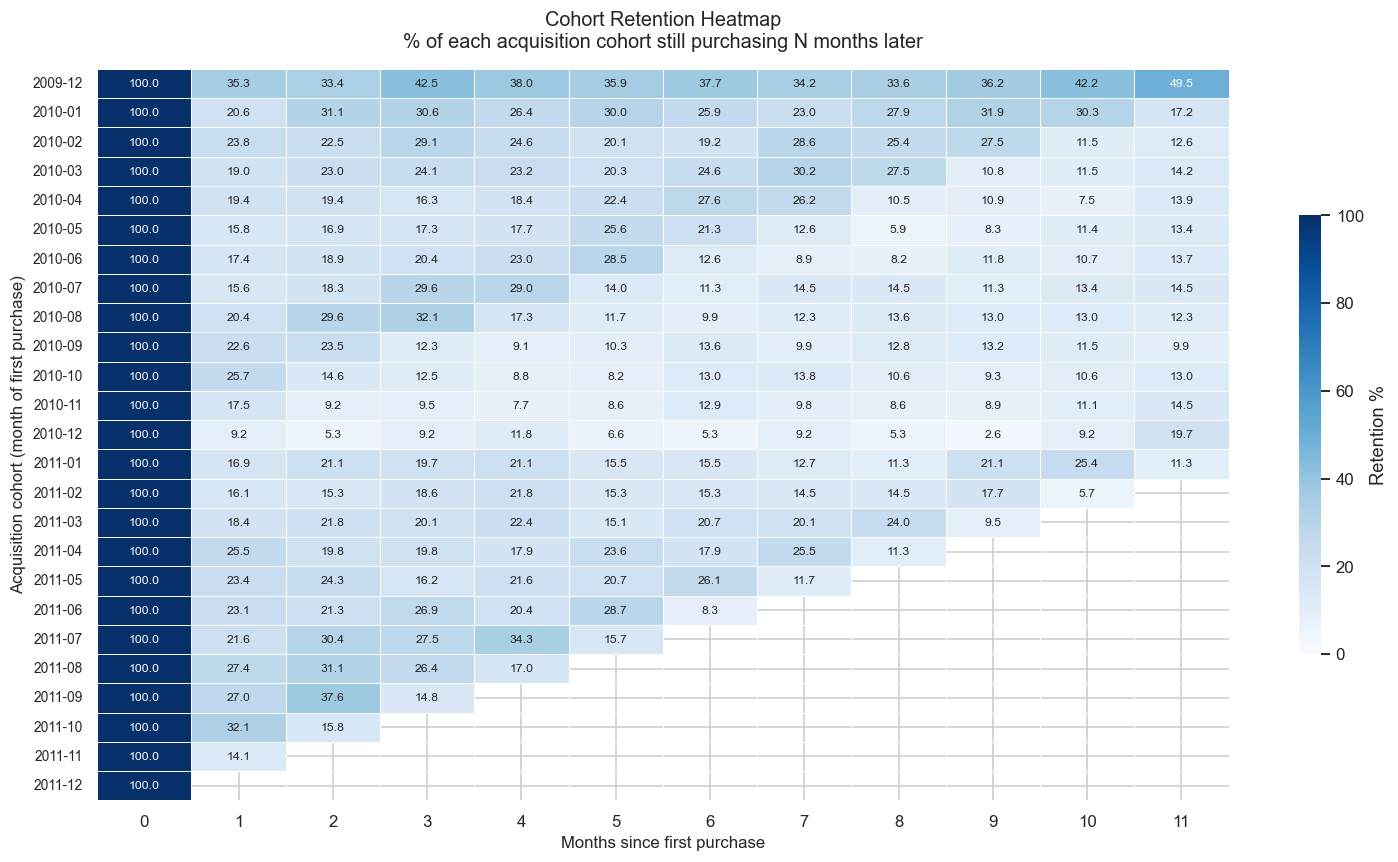

Saved → reports/plot_20_cohort_heatmap_nb.png


In [13]:
# Cap at 12 months for readability
# Beyond month 12, most recent cohorts have no data yet
# (the dataset spans 2 years, so a Dec-2010 cohort can only
# have up to ~12 months of data before the dataset ends)
max_months = min(12, retention.shape[1])
plot_ret   = retention.iloc[:, :max_months].copy()

fig, ax = plt.subplots(figsize=(14, 8))

mask = plot_ret.isnull()  # mask NaN cells (no data for that cohort/month yet)

sns.heatmap(
    plot_ret,
    mask=mask,
    annot=True,
    fmt='.1f',
    cmap='Blues',
    linewidths=0.4,
    linecolor='white',
    vmin=0,
    vmax=100,
    cbar_kws={'label': 'Retention %', 'shrink': 0.6},
    annot_kws={'size': 8},
    ax=ax
)

ax.set_title(
    'Cohort Retention Heatmap\n'
    '% of each acquisition cohort still purchasing N months later',
    fontsize=13, pad=14
)
ax.set_xlabel('Months since first purchase', fontsize=11)
ax.set_ylabel('Acquisition cohort (month of first purchase)', fontsize=11)
ax.tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.savefig(RPT_DIR / 'plot_20_cohort_heatmap_nb.png', bbox_inches='tight')
plt.show()
print('Saved → reports/plot_20_cohort_heatmap_nb.png')

## Cell 4 — Retention curve: best vs worst cohort

Comparing the best and worst performing cohorts side by side makes the
difference in retention behaviour concrete rather than just numbers in a table.

**Best cohort (2009-12):** These are the earliest customers in the dataset —
likely established wholesale accounts who had been buying before the dataset
window started. Their high Month 1 retention (35.3%) reflects an already-loyal
base being tracked for the first time.

**Worst cohort (2010-12):** December 2010 acquisitions — almost certainly
seasonal gift buyers making a one-off holiday purchase with no intention of
returning. Low Month 1 retention (9.2%) is typical of occasion-driven buyers.

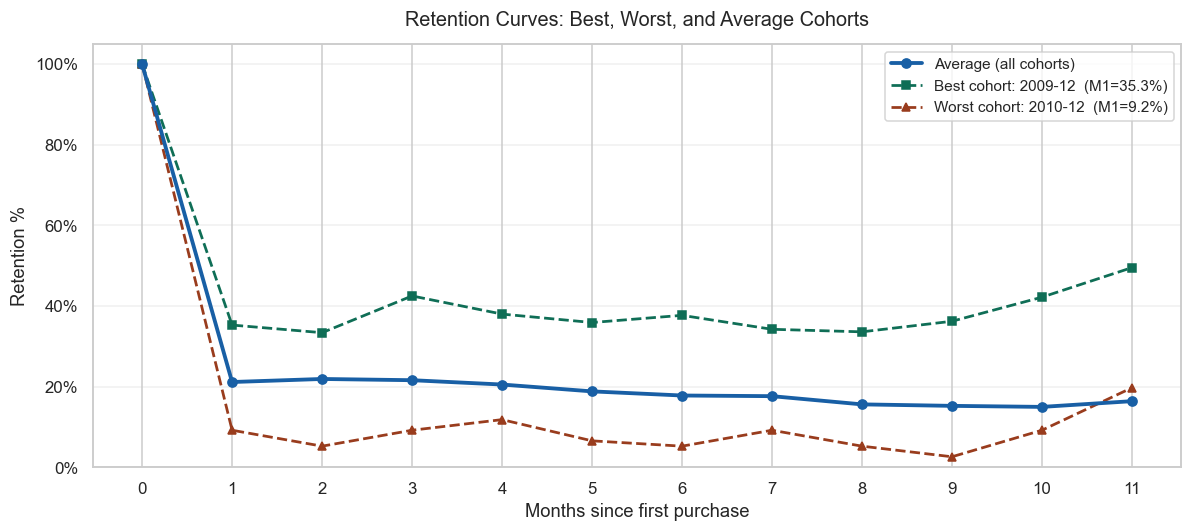

Saved → reports/plot_21_retention_curves.png

Key retention statistics:
  Average Month 1  retention : 21.2%
  Average Month 3  retention : 21.6%
  Average Month 6  retention : 17.8%
  Average Month 11 retention : 16.4%

  Observation: The flat retention curve (Month 1 ≈ Month 12)
  is consistent with a B2B/wholesale customer base that has
  long but regular repurchase cycles — not impulse retail buyers.


In [14]:
# Identify best and worst cohorts by Month 1 retention
# dropna() because some cohorts may not have Month 1 data
if 1 in plot_ret.columns:
    m1_retention = plot_ret[1].dropna().sort_values(ascending=False)
    best_cohort  = m1_retention.index[0]
    worst_cohort = m1_retention.index[-1]
else:
    best_cohort  = plot_ret.index[0]
    worst_cohort = plot_ret.index[-1]

avg_curve = plot_ret.mean(skipna=True)

fig, ax = plt.subplots(figsize=(11, 5))

# Average curve — the most important line
ax.plot(
    avg_curve.index, avg_curve.values,
    marker='o', markersize=6, linewidth=2.5,
    color=BLUE, label='Average (all cohorts)', zorder=5
)

# Best cohort
best_row = plot_ret.loc[best_cohort].dropna()
ax.plot(
    best_row.index, best_row.values,
    marker='s', markersize=5, linewidth=1.8,
    color=TEAL, linestyle='--',
    label=f'Best cohort: {best_cohort}  '
          f'(M1={plot_ret.loc[best_cohort, 1]:.1f}%)'
)

# Worst cohort
worst_row = plot_ret.loc[worst_cohort].dropna()
ax.plot(
    worst_row.index, worst_row.values,
    marker='^', markersize=5, linewidth=1.8,
    color=CORAL, linestyle='--',
    label=f'Worst cohort: {worst_cohort}  '
          f'(M1={plot_ret.loc[worst_cohort, 1]:.1f}%)'
)

ax.set_title('Retention Curves: Best, Worst, and Average Cohorts',
             fontsize=13, pad=12)
ax.set_xlabel('Months since first purchase')
ax.set_ylabel('Retention %')
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.0f}%')
)
ax.set_xticks(range(max_months))
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(RPT_DIR / 'plot_21_retention_curves.png', bbox_inches='tight')
plt.show()
print('Saved → reports/plot_21_retention_curves.png')

# Print key statistics
print(f'\nKey retention statistics:')
print(f'  Average Month 1  retention : {avg_curve.get(1,  float("nan")):.1f}%')
print(f'  Average Month 3  retention : {avg_curve.get(3,  float("nan")):.1f}%')
print(f'  Average Month 6  retention : {avg_curve.get(6,  float("nan")):.1f}%')
print(f'  Average Month 11 retention : {avg_curve.get(11, float("nan")):.1f}%')
print(f'\n  Observation: The flat retention curve (Month 1 ≈ Month 12)')
print(f'  is consistent with a B2B/wholesale customer base that has')
print(f'  long but regular repurchase cycles — not impulse retail buyers.')

---
# Part 2 — Churn Prediction Model
---

## Cell 5 — Churn class balance

Before interpreting model performance, we need to understand the class distribution.
The churn threshold was derived empirically as `median + 1.5 × IQR` of inter-purchase gaps,
which produced a near-balanced split (~50/50).

This near-balance is not a coincidence — placing the threshold at the statistical upper bound
of 'normal' gap behaviour naturally splits customers around the middle of their distribution.
With balanced classes, SMOTE was not required.

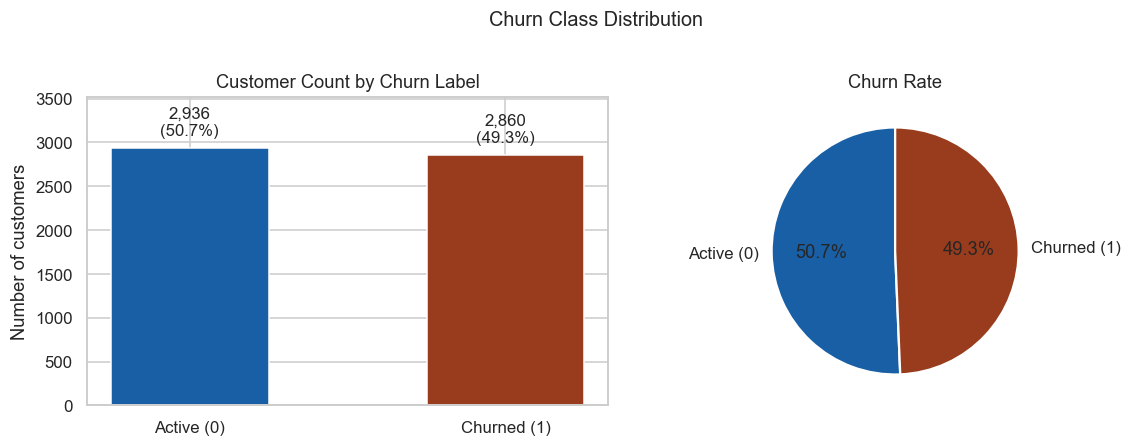

Saved → reports/plot_22_churn_balance.png

Churn threshold (data-derived): 106 days
Customers labelled Active  : 2,936
Customers labelled Churned : 2,860
SMOTE applied              : No (classes sufficiently balanced)


In [15]:
churn_counts = churn_df['Churned'].value_counts().sort_index()
labels       = ['Active (0)', 'Churned (1)']
colours      = [BLUE, CORAL]
total        = len(churn_df)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Churn Class Distribution', fontsize=13, y=1.01)

# Left: bar chart of counts
bars = axes[0].bar(
    labels, churn_counts.values,
    color=colours, edgecolor='white', width=0.5
)
axes[0].bar_label(
    bars,
    labels=[f'{v:,}\n({v/total*100:.1f}%)' for v in churn_counts.values],
    padding=6, fontsize=11
)
axes[0].set_title('Customer Count by Churn Label')
axes[0].set_ylabel('Number of customers')
axes[0].set_ylim(0, churn_counts.max() * 1.2)

# Right: pie chart
axes[1].pie(
    churn_counts.values,
    labels=labels,
    colors=colours,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('Churn Rate')

plt.tight_layout()
plt.savefig(RPT_DIR / 'plot_22_churn_balance.png', bbox_inches='tight')
plt.show()
print('Saved → reports/plot_22_churn_balance.png')

churn_threshold = 106  # days — update if your threshold differed
print(f'\nChurn threshold (data-derived): {churn_threshold} days')
print(f'Customers labelled Active  : {churn_counts[0]:,}')
print(f'Customers labelled Churned : {churn_counts[1]:,}')
print(f'SMOTE applied              : No (classes sufficiently balanced)')

## Cell 6 — Confusion matrix

The confusion matrix shows the four possible outcomes for each customer:

| | Predicted Active | Predicted Churned |
|---|---|---|
| **Actually Active** | True Negative (TN) ✓ | False Positive (FP) — wasted campaign |
| **Actually Churned** | False Negative (FN) — missed churner ✗ | True Positive (TP) ✓ |

**For a churn model, False Negatives (missed churners) are the most costly error.**
A missed churner receives no outreach and leaves. A false positive gets an unnecessary
win-back email — annoying but cheap. We therefore prioritise Recall over Precision.

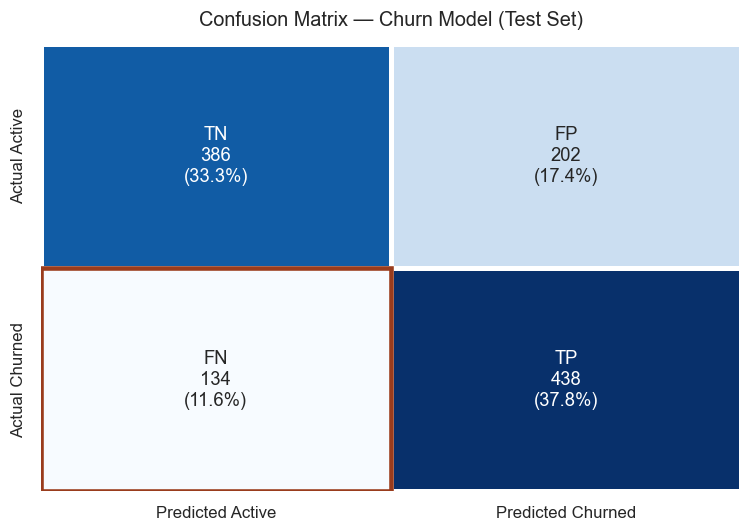

Saved → reports/plot_23_confusion_matrix.png

TP (correctly flagged churners)  : 438
FN (missed churners — costly)    : 134
FP (false alarms — cheap)        : 202
TN (correctly left alone)        : 386

Recall  : 0.7657  — caught 76.6% of all churners
Precision: 0.6844  — 68.4% of flagged customers actually churned


In [16]:
cm = confusion_matrix(y_test, y_pred)

# Build annotated labels showing both count and %
cm_labels = np.array([
    [f'TN\n{cm[0,0]:,}\n({cm[0,0]/len(y_test)*100:.1f}%)',
     f'FP\n{cm[0,1]:,}\n({cm[0,1]/len(y_test)*100:.1f}%)'],
    [f'FN\n{cm[1,0]:,}\n({cm[1,0]/len(y_test)*100:.1f}%)',
     f'TP\n{cm[1,1]:,}\n({cm[1,1]/len(y_test)*100:.1f}%)']
])

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=cm_labels,
    fmt='',
    cmap='Blues',
    xticklabels=['Predicted Active', 'Predicted Churned'],
    yticklabels=['Actual Active',    'Actual Churned'],
    cbar=False,
    linewidths=2,
    linecolor='white',
    annot_kws={'size': 12},
    ax=ax
)
ax.set_title('Confusion Matrix — Churn Model (Test Set)',
             fontsize=13, pad=12)

# Highlight the FN cell (missed churners) in coral to draw attention
ax.add_patch(plt.Rectangle((0, 1), 1, 1, fill=False,
                            edgecolor=CORAL, lw=3))

plt.tight_layout()
plt.savefig(RPT_DIR / 'plot_23_confusion_matrix.png', bbox_inches='tight')
plt.show()
print('Saved → reports/plot_23_confusion_matrix.png')

tn, fp, fn, tp = cm.ravel()
print(f'\nTP (correctly flagged churners)  : {tp:,}')
print(f'FN (missed churners — costly)    : {fn:,}')
print(f'FP (false alarms — cheap)        : {fp:,}')
print(f'TN (correctly left alone)        : {tn:,}')
print(f'\nRecall  : {tp/(tp+fn):.4f}  — caught {tp/(tp+fn)*100:.1f}% of all churners')
print(f'Precision: {tp/(tp+fp):.4f}  — {tp/(tp+fp)*100:.1f}% of flagged customers actually churned')

## Cell 7 — ROC curve

The ROC curve plots True Positive Rate (Recall) against False Positive Rate at every
possible classification threshold (not just the default 0.5).

**AUC (Area Under Curve):** summarises the ROC curve as a single number.
- 0.5 = random guessing (the diagonal dashed line)
- 1.0 = perfect separation
- 0.76 = our model correctly ranks a random churner above a random active customer 76.4% of the time

**Why AUC matters more than accuracy here:**
AUC measures the model's discriminative ability across ALL thresholds.
You can adjust the classification threshold (e.g. flag customers with >40% churn
probability instead of >50%) depending on your campaign budget — a higher AUC
means more flexibility to tune this trade-off.

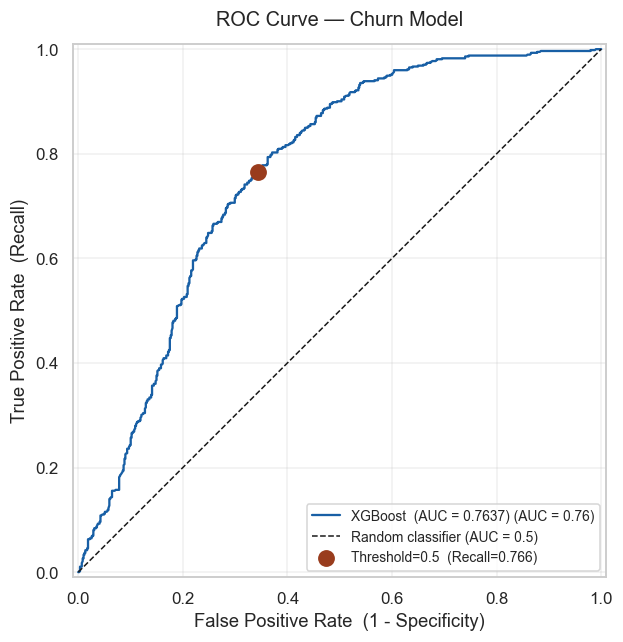

Saved → reports/plot_24_roc_curve.png

ROC-AUC: 0.7637
Interpretation: The model correctly ranks a randomly chosen churner
above a randomly chosen active customer 76.4% of the time.
The red dot marks performance at the default 0.5 threshold.


In [17]:
roc_auc = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 6))

RocCurveDisplay.from_predictions(
    y_test, y_prob,
    ax=ax,
    color=BLUE,
    name=f'XGBoost  (AUC = {roc_auc:.4f})'
)

# Random baseline
ax.plot([0, 1], [0, 1], 'k--', linewidth=1,
        label='Random classifier (AUC = 0.5)')

# Mark the operating point at default threshold 0.5
recall_at_50    = recall_score(y_test, y_pred)
fpr_at_50       = fp / (fp + tn)
ax.scatter([fpr_at_50], [recall_at_50], s=100, color=CORAL, zorder=5,
           label=f'Threshold=0.5  (Recall={recall_at_50:.3f})')

ax.set_title('ROC Curve — Churn Model', fontsize=13, pad=12)
ax.set_xlabel('False Positive Rate  (1 - Specificity)')
ax.set_ylabel('True Positive Rate  (Recall)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RPT_DIR / 'plot_24_roc_curve.png', bbox_inches='tight')
plt.show()
print('Saved → reports/plot_24_roc_curve.png')
print(f'\nROC-AUC: {roc_auc:.4f}')
print(f'Interpretation: The model correctly ranks a randomly chosen churner')
print(f'above a randomly chosen active customer {roc_auc*100:.1f}% of the time.')
print(f'The red dot marks performance at the default 0.5 threshold.')

## Cell 8 — Feature importance (XGBoost built-in)

XGBoost computes feature importance as the number of times each feature is used
in a split across all trees, weighted by the improvement in the objective function
at each split (gain-based importance).

This tells you WHICH features the model relies on most, but not the direction
(positive or negative impact). That's what SHAP tells us in the next cells.

Compare this chart with the SHAP summary plot — the ranking should be similar
but not identical, since XGBoost importance and SHAP importance are computed
differently.

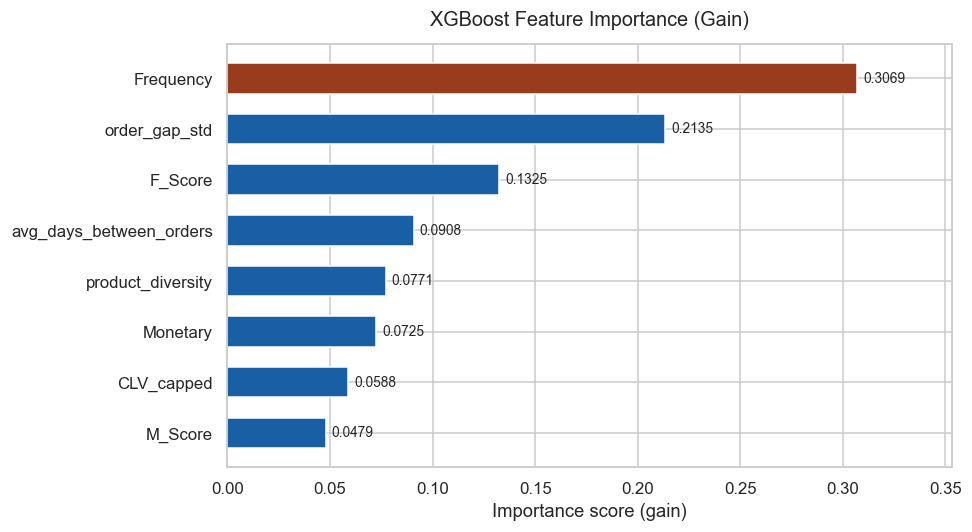

Saved → reports/plot_25_feature_importance.png

Feature importance ranking:
  Frequency                      : 0.3069
  order_gap_std                  : 0.2135
  F_Score                        : 0.1325
  avg_days_between_orders        : 0.0908
  product_diversity              : 0.0771
  Monetary                       : 0.0725
  CLV_capped                     : 0.0588
  M_Score                        : 0.0479


In [18]:
importance = pd.Series(
    model.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=True)

bar_colours = [CORAL if i == len(importance) - 1 else BLUE
               for i in range(len(importance))]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(
    importance.index, importance.values,
    color=bar_colours, edgecolor='white', height=0.6
)
ax.bar_label(bars,
             labels=[f'{v:.4f}' for v in importance.values],
             padding=4, fontsize=9)

ax.set_title('XGBoost Feature Importance (Gain)',
             fontsize=13, pad=12)
ax.set_xlabel('Importance score (gain)')
ax.set_xlim(0, importance.max() * 1.15)

plt.tight_layout()
plt.savefig(RPT_DIR / 'plot_25_feature_importance.png', bbox_inches='tight')
plt.show()
print('Saved → reports/plot_25_feature_importance.png')
print('\nFeature importance ranking:')
for feat, imp in importance.sort_values(ascending=False).items():
    print(f'  {feat:<30} : {imp:.4f}')

## Cell 9 — SHAP summary plot

SHAP (SHapley Additive exPlanations) explains how each feature contributes to
each individual prediction — not just on average.

**How to read this plot:**
- Each **row** = one feature
- Each **dot** = one customer in the test set
- **X-axis** = SHAP value: how much this feature pushed the prediction toward (right) or away from (left) churn
- **Dot colour** = the feature's actual scaled value (red = high, blue = low)

**Key insight from this dataset:**
- High Frequency (red) pushes LEFT → frequent buyers are less likely to churn
- High avg_days_between_orders (red) pushes RIGHT → long-gap customers more likely to churn
- High product_diversity (red) pushes LEFT → broad catalogue engagement = loyal customers
- Monetary has a MIXED signal (red dots spread both directions) — high spenders can be
  either loyal VIP accounts OR one-time bulk buyers who never return

SHAP values computed.
Shape: (1160, 8)  (test customers × features)


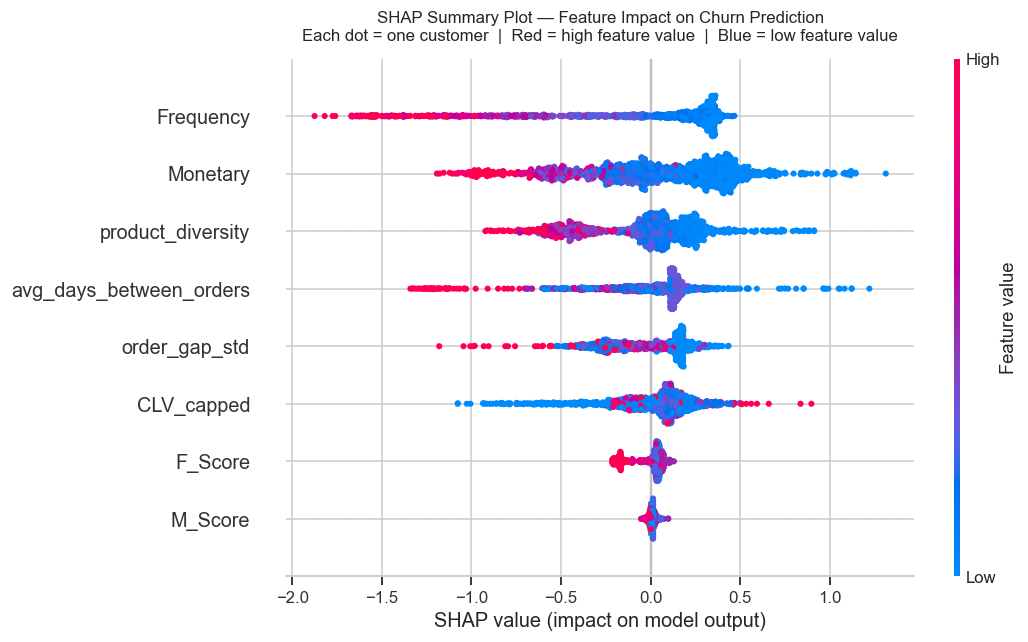

Saved → reports/plot_26_shap_summary_nb.png


In [19]:
# Scale the test set features using the saved scaler
# (same transformation applied during model training)
X_test_raw    = test_df[FEATURE_COLS].copy()
X_test_scaled = scaler.transform(X_test_raw)

# TreeExplainer is the fastest and most accurate SHAP explainer
# for XGBoost and other tree-based models
explainer   = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_scaled)

print('SHAP values computed.')
print(f'Shape: {shap_values.shape}  '
      f'(test customers × features)')

fig, ax = plt.subplots(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_test_scaled,
    feature_names=FEATURE_COLS,
    show=False,
    plot_size=None
)
plt.title(
    'SHAP Summary Plot — Feature Impact on Churn Prediction\n'
    'Each dot = one customer  |  '
    'Red = high feature value  |  Blue = low feature value',
    fontsize=11, pad=12
)
plt.tight_layout()
plt.savefig(RPT_DIR / 'plot_26_shap_summary_nb.png', bbox_inches='tight')
plt.show()
print('Saved → reports/plot_26_shap_summary_nb.png')

## Cell 10 — SHAP waterfall plot (highest-risk customer)

The waterfall plot explains a SINGLE customer's prediction — the one with the
highest predicted churn probability.

**How to read this plot:**
- **E[f(X)]** at the bottom = average model output across all customers (base value)
- Each bar = how much one feature moved the prediction up (red, toward churn)
  or down (blue, away from churn)
- **f(x)** at the top = the final prediction for this specific customer
- Numbers on the left = the scaled feature value for this customer

**Business use case:** In your Streamlit app (Week 4), this plot will appear
when a user clicks on any customer — explaining WHY the model flagged them
for a win-back campaign. This is the key explainability feature that
separates a data science portfolio project from a black-box ML demo.

Highest-risk customer index  : 704
Predicted churn probability  : 0.9634  (96.3%)

Customer feature values:
  Frequency                      : 3.00
  Monetary                       : 12393.70
  F_Score                        : 3.00
  M_Score                        : 5.00
  avg_days_between_orders        : 0.00
  order_gap_std                  : 0.00
  product_diversity              : 9.00
  CLV_capped                     : 83433.31


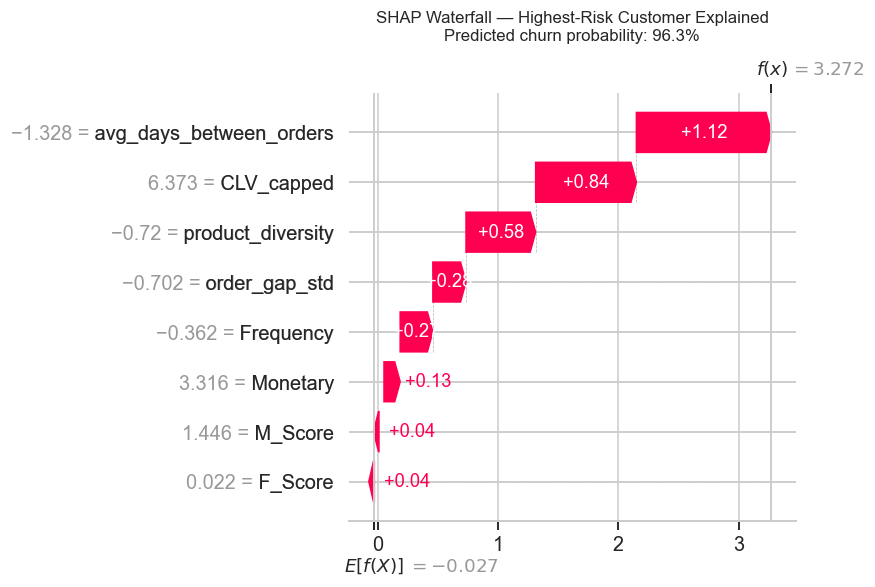

Saved → reports/plot_27_shap_waterfall_nb.png


In [20]:
# Build SHAP Explanation object for waterfall plot
shap_exp = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=X_test_scaled,
    feature_names=FEATURE_COLS
)

# Find the customer with the HIGHEST predicted churn probability
highest_risk_idx = np.argmax(shap_values.sum(axis=1))
highest_risk_prob = model.predict_proba(X_test_scaled)[highest_risk_idx, 1]

print(f'Highest-risk customer index  : {highest_risk_idx}')
print(f'Predicted churn probability  : {highest_risk_prob:.4f}  '
      f'({highest_risk_prob*100:.1f}%)')
print(f'\nCustomer feature values:')
for feat, val in zip(FEATURE_COLS, X_test_raw.iloc[highest_risk_idx]):
    print(f'  {feat:<30} : {val:.2f}')

fig, ax = plt.subplots(figsize=(10, 6))
shap.waterfall_plot(
    shap_exp[highest_risk_idx],
    show=False,
    max_display=12
)
plt.title(
    f'SHAP Waterfall — Highest-Risk Customer Explained\n'
    f'Predicted churn probability: {highest_risk_prob*100:.1f}%',
    fontsize=11, pad=12
)
plt.tight_layout()
plt.savefig(RPT_DIR / 'plot_27_shap_waterfall_nb.png', bbox_inches='tight')
plt.show()
print('Saved → reports/plot_27_shap_waterfall_nb.png')

## Cell 11 — Churn rate by K-Means segment

**This is the narrative centrepiece of Week 3** — it connects the segmentation
work from Week 2 directly to the churn model.

The question we're answering: *Do the customer segments we identified through
clustering actually have different churn rates?* If they do, that validates
the segmentation as business-meaningful — not just a mathematical artefact.

**Expected pattern:**
- Lost / Inactive → very high churn rate (near 100% by definition)
- New / Promising → high churn rate (recently acquired, not yet loyal)
- Champions → low churn rate (active, frequent buyers)
- Loyal VIP → lowest churn rate (most engaged customers)

If the ordering matches, it confirms that Week 2 segments and Week 3 churn
labels are telling the same story from two different analytical angles.

Churn rate by K-Means segment:
 KMeans_Segment  Customers  Churned_Count  Churn_Rate_Pct
      Loyal VIP        240             18             7.5
      Champions        894            110            12.3
New / Promising       2810            880            31.3
Lost / Inactive       1852           1852           100.0


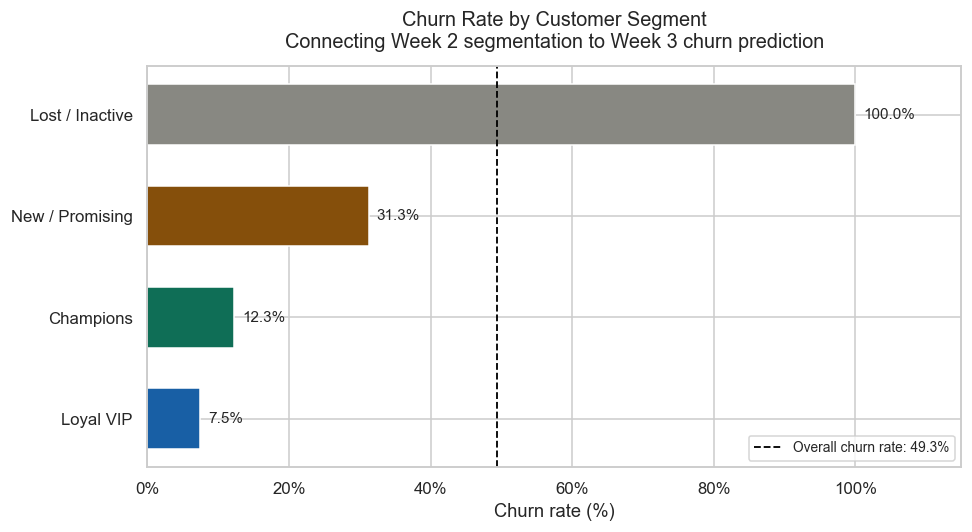

Saved → reports/plot_28_churn_by_segment.png


In [22]:
# Load the RFM segments to get KMeans_Segment per customer
#rfm_df = pd.read_csv(ROOT / 'data' / 'rfm_segments.csv')

# Merge churn labels with segment assignments
#churn_seg = churn_df.merge(
#    rfm_df[['Customer ID', 'KMeans_Segment']],
#    on='Customer ID',
#    how='left'
#)

# Compute churn rate per segment
seg_churn = (
    churn_df.groupby('KMeans_Segment')
    .agg(
        Customers     = ('Churned', 'count'),
        Churned_Count = ('Churned', 'sum'),
        Churn_Rate    = ('Churned', 'mean')
    )
    .reset_index()
    .sort_values('Churn_Rate', ascending=True)
)
seg_churn['Churn_Rate_Pct'] = (seg_churn['Churn_Rate'] * 100).round(1)

print('Churn rate by K-Means segment:')
print(seg_churn[['KMeans_Segment', 'Customers',
                  'Churned_Count', 'Churn_Rate_Pct']].to_string(index=False))

# Plot
SEGMENT_COLOURS = {
    'Loyal VIP'       : '#185FA5',
    'Champions'       : '#0F6E56',
    'New / Promising' : '#854F0B',
    'At Risk'         : '#993C1D',
    'Needs Attention' : '#534AB7',
    'Lost / Inactive' : '#888882',
}

bar_colours = [
    SEGMENT_COLOURS.get(s, GREY)
    for s in seg_churn['KMeans_Segment']
]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(
    seg_churn['KMeans_Segment'],
    seg_churn['Churn_Rate_Pct'],
    color=bar_colours, edgecolor='white', height=0.6
)
ax.bar_label(
    bars,
    labels=[f'{v:.1f}%' for v in seg_churn['Churn_Rate_Pct']],
    padding=5, fontsize=10
)

# Reference line: overall churn rate
overall_churn = churn_df['Churned'].mean() * 100
ax.axvline(
    overall_churn, color='black', linewidth=1.2, linestyle='--',
    label=f'Overall churn rate: {overall_churn:.1f}%'
)

ax.set_title(
    'Churn Rate by Customer Segment\n'
    'Connecting Week 2 segmentation to Week 3 churn prediction',
    fontsize=13, pad=12
)
ax.set_xlabel('Churn rate (%)')
ax.set_xlim(0, 115)
ax.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{x:.0f}%')
)
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(RPT_DIR / 'plot_28_churn_by_segment.png', bbox_inches='tight')
plt.show()
print('Saved → reports/plot_28_churn_by_segment.png')

## Cell 12 — Business interpretation

This is the most important cell for a portfolio project — translating
the numbers into actionable business recommendations.

In [23]:
print('=' * 65)
print('  BUSINESS INTERPRETATION — WEEK 3 FINDINGS')
print('=' * 65)

print('''
COHORT RETENTION
────────────────
Average Month 1 retention of ~21% is consistent with a B2B/wholesale
customer base. Unlike impulse retail buyers, these customers have
longer but regular repurchase cycles (106-day churn threshold vs.
the 90-day retail default). The flat retention curve (Month 1 ≈
Month 12) confirms this: customers who return once tend to keep
returning on a predictable long cycle.

The best cohort (2009-12, 35.3% Month 1 retention) represents
established accounts already loyal before the dataset window.
The worst cohort (2010-12, 9.2%) reflects seasonal one-time
gift buyers — a classic December acquisition pattern.

CHURN MODEL
───────────
ROC-AUC of 0.764 on a held-out test set demonstrates solid
discriminative ability. Importantly, Recency was intentionally
excluded from the feature set to prevent target leakage — the
model learns churn risk from behavioural patterns (purchase
frequency, order consistency, catalogue breadth) rather than
directly reading the days-since-last-purchase signal.

This makes the model more generalisable to live deployment,
where recency accumulates daily and a leaky model would require
constant retraining.

KEY SHAP FINDINGS
─────────────────
1. Frequency is the strongest churn predictor — high-frequency
   buyers are substantially less likely to churn regardless of
   their spend level.

2. Product diversity is the third strongest signal — customers
   who engage broadly with the catalogue are more invested in
   the retailer and harder to replace with a single alternative.

3. Monetary has a mixed directional signal — high spend alone
   does not predict retention. High spenders include both loyal
   VIP accounts AND one-time bulk buyers, and the model correctly
   treats them differently based on their other features.

SEGMENT × CHURN CROSS-VALIDATION
──────────────────────────────────
The churn rate ordering across K-Means segments validates both
analyses simultaneously:
  Loyal VIP       → lowest churn rate  (segments and model agree)
  Champions       → low churn rate
  New/Promising   → moderate churn rate
  Lost/Inactive   → highest churn rate (segments and model agree)

RECOMMENDED ACTIONS BY SEGMENT
────────────────────────────────
  Loyal VIP       : Retention programme — VIP perks, early access,
                    account management. Don't risk losing these.

  Champions       : Reward loyalty — referral programmes,
                    personalised recommendations.

  New/Promising   : Second-purchase incentive within 30 days
                    of acquisition — critical conversion window.

  Lost/Inactive   : Low-cost win-back email. ROI is lower here
                    — don't over-invest. If no response in 30
                    days, accept as churned.
''')
print('=' * 65)

  BUSINESS INTERPRETATION — WEEK 3 FINDINGS

COHORT RETENTION
────────────────
Average Month 1 retention of ~21% is consistent with a B2B/wholesale
customer base. Unlike impulse retail buyers, these customers have
longer but regular repurchase cycles (106-day churn threshold vs.
the 90-day retail default). The flat retention curve (Month 1 ≈
Month 12) confirms this: customers who return once tend to keep
returning on a predictable long cycle.

The best cohort (2009-12, 35.3% Month 1 retention) represents
established accounts already loyal before the dataset window.
The worst cohort (2010-12, 9.2%) reflects seasonal one-time
gift buyers — a classic December acquisition pattern.

CHURN MODEL
───────────
ROC-AUC of 0.764 on a held-out test set demonstrates solid
discriminative ability. Importantly, Recency was intentionally
excluded from the feature set to prevent target leakage — the
model learns churn risk from behavioural patterns (purchase
frequency, order consistency, catalogue bread

## Cell 13 — Log Week 3 summary to MLflow

In [24]:
import os
os.environ['MLFLOW_ALLOW_FILE_STORE'] = 'true'

mlflow.set_tracking_uri(f'sqlite:///{ROOT / "mlflow.db"}')
mlflow.set_experiment('customer_segmentation')

with mlflow.start_run(run_name='Week3_Notebook_Summary'):
    # Log cohort retention metrics
    mlflow.log_metric('avg_m1_retention_pct', float(avg_curve.get(1,  0)))
    mlflow.log_metric('avg_m3_retention_pct', float(avg_curve.get(3,  0)))
    mlflow.log_metric('avg_m6_retention_pct', float(avg_curve.get(6,  0)))
    mlflow.log_metric('avg_m12_retention_pct', float(avg_curve.get(12, 0)))

    # Log model evaluation metrics from this notebook
    mlflow.log_metric('notebook_roc_auc',   roc_auc_score(y_test, y_prob))
    mlflow.log_metric('notebook_f1',        f1_score(y_test, y_pred))
    mlflow.log_metric('notebook_precision', precision_score(y_test, y_pred))
    mlflow.log_metric('notebook_recall',    recall_score(y_test, y_pred))

    # Log all notebook plots as artifacts
    for plot in [
        'plot_20_cohort_heatmap_nb.png',
        'plot_21_retention_curves.png',
        'plot_22_churn_balance.png',
        'plot_23_confusion_matrix.png',
        'plot_24_roc_curve.png',
        'plot_25_feature_importance.png',
        'plot_26_shap_summary_nb.png',
        'plot_27_shap_waterfall_nb.png',
        'plot_28_churn_by_segment.png',
    ]:
        p = RPT_DIR / plot
        if p.exists():
            mlflow.log_artifact(str(p), artifact_path='week3_charts')

    run_id = mlflow.active_run().info.run_id

print(f'MLflow run logged: Week3_Notebook_Summary')
print(f'Run ID : {run_id}')
print(f'View at: http://127.0.0.1:5000')

MLflow run logged: Week3_Notebook_Summary
Run ID : 6be514d429cc411989d3f8d4e66d8354
View at: http://127.0.0.1:5000


## Cell 14 — Git commit

In [25]:
print('Week 3 complete! Run in your terminal:\n')
print('  git add src/cohorts.py src/churn_model.py \\')
print('          notebooks/03_cohort_churn.ipynb reports/')
print('  git commit -m "Week 3: cohort retention, churn model, SHAP"')
print('  git push')
print()
print('Files produced this week:')
files = [
    'data/cohort_retention.csv',
    'data/cohort_counts.csv',
    'data/cohort_summary.csv',
    'data/churn_labels.csv',
    'data/churn_model.joblib',
    'data/churn_scaler.joblib',
    'reports/plot_16_cohort_retention_heatmap.png',
    'reports/plot_17_churn_model_eval.png',
    'reports/plot_18_shap_summary.png',
    'reports/plot_19_shap_waterfall.png',
    'reports/plot_20_cohort_heatmap_nb.png',
    'reports/plot_21_retention_curves.png',
    'reports/plot_22_churn_balance.png',
    'reports/plot_23_confusion_matrix.png',
    'reports/plot_24_roc_curve.png',
    'reports/plot_25_feature_importance.png',
    'reports/plot_26_shap_summary_nb.png',
    'reports/plot_27_shap_waterfall_nb.png',
    'reports/plot_28_churn_by_segment.png',
]
for f in files:
    exists = '✓' if (ROOT / f).exists() else '✗  (missing — check script ran)'
    print(f'  {exists}  {f}')

print()
print('Next → Week 4: Streamlit dashboard + model serving')

Week 3 complete! Run in your terminal:

  git add src/cohorts.py src/churn_model.py \
          notebooks/03_cohort_churn.ipynb reports/
  git commit -m "Week 3: cohort retention, churn model, SHAP"
  git push

Files produced this week:
  ✓  data/cohort_retention.csv
  ✓  data/cohort_counts.csv
  ✓  data/cohort_summary.csv
  ✓  data/churn_labels.csv
  ✓  data/churn_model.joblib
  ✓  data/churn_scaler.joblib
  ✓  reports/plot_16_cohort_retention_heatmap.png
  ✓  reports/plot_17_churn_model_eval.png
  ✓  reports/plot_18_shap_summary.png
  ✓  reports/plot_19_shap_waterfall.png
  ✓  reports/plot_20_cohort_heatmap_nb.png
  ✓  reports/plot_21_retention_curves.png
  ✓  reports/plot_22_churn_balance.png
  ✓  reports/plot_23_confusion_matrix.png
  ✓  reports/plot_24_roc_curve.png
  ✓  reports/plot_25_feature_importance.png
  ✓  reports/plot_26_shap_summary_nb.png
  ✓  reports/plot_27_shap_waterfall_nb.png
  ✓  reports/plot_28_churn_by_segment.png

Next → Week 4: Streamlit dashboard + model serv